# SVM Classification: Employee Attrition Prediction
## Máquinas de Soporte Vectorial: Predicción de Rotación de Empleados

**Author / Autora:** María Regina Castillo Treviño · [github.com/ReginaPema](https://github.com/ReginaPema)

**Dataset:** `recursos_humanos.csv` — 14,999 employees × 9 features | Target: `left` (0=stayed, 1=left)

**Objective / Objetivo:**  
EN · Compare all four SVM kernels (Linear, Polynomial, RBF, Sigmoid) for binary classification of employee attrition, selecting the optimal kernel based on Accuracy, F1, Precision, Recall and AUC-ROC.

ES · Comparar los cuatro kernels de SVM (Lineal, Polinomial, RBF, Sigmoide) para clasificación binaria de rotación de empleados, seleccionando el kernel óptimo basado en Accuracy, F1, Precision, Recall y AUC-ROC.

**Techniques / Técnicas:** SVM · 4 Kernels (Linear, Poly, RBF, Sigmoid) · Confusion Matrix · ROC Curve · Kernel Comparison  
**Libraries / Librerías:** `pandas` · `numpy` · `sklearn` · `matplotlib` · `seaborn`

---

# Importación de Librerías y Carga de Datos

In [1]:
# ============================================================
# IMPORTACIÓN DE LIBRERÍAS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_curve, auc)
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# ============================================================
# CARGA DE DATOS
# ============================================================
df = pd.read_csv('recursos_humanos.csv')

print('=' * 65)
print("INFORMACIÓN GENERAL DEL DATASET")
print('=' * 65)
print(f"\n★ Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"\n★ 5 filas aleatorias:")
print(df.sample(5, random_state=42))
print(f"\n★ Información del dataset:")
print(df.info())
print(f"\n★ Estadísticas descriptivas:")
print(df.describe())

INFORMACIÓN GENERAL DEL DATASET

★ Dimensiones: 14999 filas x 10 columnas

★ 5 filas aleatorias:
      satisfaction_level  last_evaluation  number_project  \
6723                0.65             0.96               5   
6473                0.88             0.80               3   
4679                0.69             0.98               3   
862                 0.41             0.47               2   
7286                0.87             0.76               5   

      average_montly_hours  time_spend_company  Work_accident  left  \
6723                   226                   2              1     0   
6473                   166                   2              0     0   
4679                   214                   2              0     0   
862                    154                   3              0     1   
7286                   254                   2              1     0   

      promotion_last_5years      sales  salary  
6723                      0  marketing  medium  
6473       

# Preprocesamiento

In [3]:
# ============================================================
# RE-CODIFICACIÓN DE VARIABLES CATEGÓRICAS
# ============================================================
print('\n' + '=' * 65)
print("PREPROCESAMIENTO DE DATOS")
print('=' * 65)

# Variables categóricas antes de codificar
print(f"\n★ Variables categóricas detectadas:")
for col in df.select_dtypes(include='object').columns:
    print(f"   {col}: {df[col].unique()}")

# Aplicar get_dummies
df_encoded = pd.get_dummies(df, columns=['sales', 'salary'], drop_first=False, dtype=int)

print(f"\n★ Dimensiones después de codificación: {df_encoded.shape}")
print(f"\n★ Columnas resultantes:")
for i, col in enumerate(df_encoded.columns, 1):
    print(f"   {i:2d}. {col}")

# ============================================================
# SEPARACIÓN FEATURES / OBJETIVO
# ============================================================
X = df_encoded.drop('left', axis=1)
y = df_encoded['left']

# ============================================================
# DIVISIÓN ENTRENAMIENTO / PRUEBA
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# ============================================================
# ESTANDARIZACIÓN ➝ obligatoria para SVM porque es muy sensible a las escalas
# ============================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"\n★ División del dataset:")
print(f"   • Entrenamiento: {X_train.shape[0]:,} registros (80.0%)")
print(f"   • Prueba: {X_test.shape[0]:,} registros (20.0%)")


PREPROCESAMIENTO DE DATOS

★ Variables categóricas detectadas:
   sales: ['sales' 'accounting' 'hr' 'technical' 'support' 'management' 'IT'
 'product_mng' 'marketing' 'RandD']
   salary: ['low' 'medium' 'high']

★ Dimensiones después de codificación: (14999, 21)

★ Columnas resultantes:
    1. satisfaction_level
    2. last_evaluation
    3. number_project
    4. average_montly_hours
    5. time_spend_company
    6. Work_accident
    7. left
    8. promotion_last_5years
    9. sales_IT
   10. sales_RandD
   11. sales_accounting
   12. sales_hr
   13. sales_management
   14. sales_marketing
   15. sales_product_mng
   16. sales_sales
   17. sales_support
   18. sales_technical
   19. salary_high
   20. salary_low
   21. salary_medium

★ División del dataset:
   • Entrenamiento: 11,999 registros (80.0%)
   • Prueba: 3,000 registros (20.0%)


# Entrenamiento de los 4 Kernels SVM

In [5]:
# ============================================================
# DEFINICIÓN DE LOS 4 KERNELS A EVALUAR
# ============================================================
kernels = {
    'Lineal':          SVC(kernel='linear',  probability=True, random_state=42),
    'Polinomial':      SVC(kernel='poly',    probability=True, random_state=42, degree=3),
    'RBF (Gaussiano)': SVC(kernel='rbf',     probability=True, random_state=42),
    'Sigmoide':        SVC(kernel='sigmoid', probability=True, random_state=42)
}

# Diccionario para almacenar resultados
resultados_svm = {}

print('\n' + '=' * 65)
print("ENTRENAMIENTO DE MODELOS SVM - 4 KERNELS")
print('=' * 65)

for nombre, modelo in kernels.items():
    print(f"\n☆ Kernel {nombre} entrenado:")
    
    # Entrenar
    modelo.fit(X_train_scaled, y_train)
    
    # Predecir
    y_pred = modelo.predict(X_test_scaled)
    y_prob = modelo.predict_proba(X_test_scaled)[:, 1]
    
    # Métricas
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    cm   = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    resultados_svm[nombre] = {
        'modelo':    modelo,
        'y_pred':    y_pred,
        'y_prob':    y_prob,
        'accuracy':  round(acc, 4),
        'precision': round(prec, 4),
        'recall':    round(rec, 4),
        'f1':        round(f1, 4),
        'auc':       round(roc_auc, 4),
        'cm':        cm,
        'fpr':       fpr,
        'tpr':       tpr,
        'reporte':   classification_report(y_test, y_pred, target_names=['No se fue (0)', 'Se fue (1)'])
    }
    
    print(f"   Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | AUC: {roc_auc:.4f}")


ENTRENAMIENTO DE MODELOS SVM - 4 KERNELS

☆ Kernel Lineal entrenado:
   Accuracy: 0.7827 | Precision: 0.5969 | Recall: 0.2675 | F1: 0.3694 | AUC: 0.8177

☆ Kernel Polinomial entrenado:
   Accuracy: 0.9440 | Precision: 0.9226 | Recall: 0.8347 | F1: 0.8765 | AUC: 0.9544

☆ Kernel RBF (Gaussiano) entrenado:
   Accuracy: 0.9527 | Precision: 0.9017 | Recall: 0.8992 | F1: 0.9004 | AUC: 0.9697

☆ Kernel Sigmoide entrenado:
   Accuracy: 0.6540 | Precision: 0.2492 | Recall: 0.2255 | F1: 0.2368 | AUC: 0.5562


# Matrices de Confusión de Los 4 Kernels

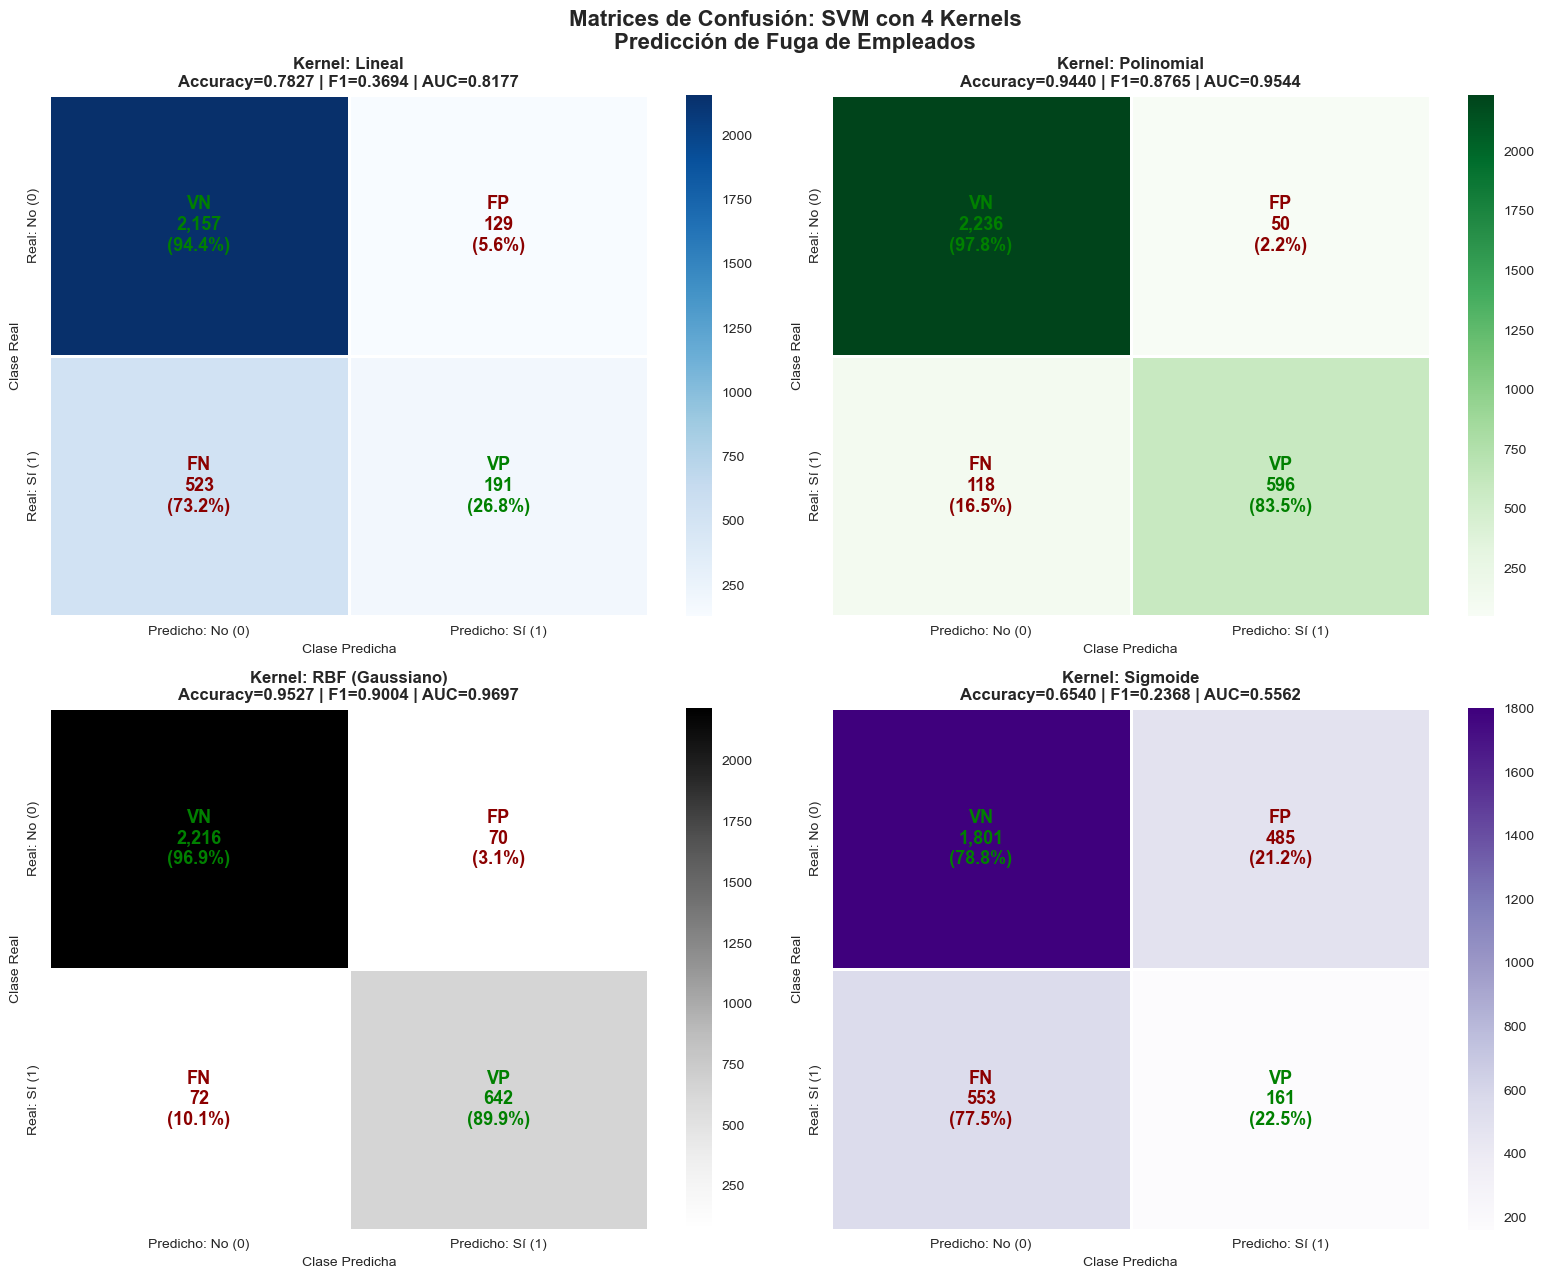

In [9]:
# ============================================================
# MAPA DE CALOR - MATRICES DE CONFUSIÓN (4 KERNELS)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 13))
fig.suptitle('Matrices de Confusión: SVM con 4 Kernels\n'
             'Predicción de Fuga de Empleados',
             fontsize=16, fontweight='bold')

colores_kernel = ['Blues', 'Greens', 'Greys', 'Purples']

for idx, (nombre, res) in enumerate(resultados_svm.items()):
    ax  = axes[idx // 2][idx % 2]
    cm  = res['cm']
    
    # Normalización por fila
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # Etiquetas
    labels = np.array([
        [f'VN\n{cm[0,0]:,}\n({cm_norm[0,0]*100:.1f}%)',
         f'FP\n{cm[0,1]:,}\n({cm_norm[0,1]*100:.1f}%)'],
        [f'FN\n{cm[1,0]:,}\n({cm_norm[1,0]*100:.1f}%)',
         f'VP\n{cm[1,1]:,}\n({cm_norm[1,1]*100:.1f}%)']
    ])
    
    sns.heatmap(cm,
                annot=labels,
                fmt='',
                cmap=colores_kernel[idx],
                cbar=True,
                linewidths=2,
                linecolor='white',
                ax=ax,
                annot_kws={'size': 13, 'weight': 'bold'},
                xticklabels=['Predicho: No (0)', 'Predicho: Sí (1)'],
                yticklabels=['Real: No (0)', 'Real: Sí (1)'])
    
    # Colorear texto
    for text in ax.texts:
        if 'VN' in text.get_text() or 'VP' in text.get_text():
            text.set_color('green')
        else:
            text.set_color('darkred')
    
    ax.set_title(f'Kernel: {nombre}\n'
                 f'Accuracy={res["accuracy"]:.4f} | '
                 f'F1={res["f1"]:.4f} | '
                 f'AUC={res["auc"]:.4f}',
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('Clase Real', fontsize=10)
    ax.set_xlabel('Clase Predicha', fontsize=10)

plt.tight_layout()
plt.savefig('svm_matrices_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

# Reportes de Clasificación Detallados

In [12]:
# ============================================================
# REPORTES DE CLASIFICACIÓN - 4 KERNELS
# ============================================================

print('\n' + '=' * 65)
print("REPORTES DE CLASIFICACIÓN: 4 KERNELS SVM")
print('=' * 65)

for nombre, res in resultados_svm.items():
    cm = res['cm']
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    print(f"""
{'⎯'*60}
 KERNEL: {nombre.upper()}
{'⎯'*60}

 ★ MATRIZ DE CONFUSIÓN:
   [[{cm[0,0]:4d}  {cm[0,1]:4d}]
    [{cm[1,0]:4d}  {cm[1,1]:4d}]]

    VN: {cm[0,0]:,} ({cm_norm[0,0]*100:.1f}% de los que se quedaron)
    FP: {cm[0,1]:,}   ({cm_norm[0,1]*100:.1f}% de los que se quedaron)
    FN: {cm[1,0]:,}   ({cm_norm[1,0]*100:.1f}% de los que se fueron)
    VP: {cm[1,1]:,}   ({cm_norm[1,1]*100:.1f}% de los que se fueron)

 ★ REPORTE DE CLASIFICACIÓN:
   {res['reporte']}
 
 ★ MÉTRICAS RESUMEN:
    • Accuracy  : {res['accuracy']:.4f} ({res['accuracy']*100:.2f}%)
    • Precision : {res['precision']:.4f} ({res['precision']*100:.2f}%)
    • Recall    : {res['recall']:.4f} ({res['recall']*100:.2f}%)
    • F1-Score  : {res['f1']:.4f}
    • AUC-ROC   : {res['auc']:.4f}
""")


REPORTES DE CLASIFICACIÓN: 4 KERNELS SVM

⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯
 KERNEL: LINEAL
⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯

 ★ MATRIZ DE CONFUSIÓN:
   [[2157   129]
    [ 523   191]]

    VN: 2,157 (94.4% de los que se quedaron)
    FP: 129   (5.6% de los que se quedaron)
    FN: 523   (73.2% de los que se fueron)
    VP: 191   (26.8% de los que se fueron)

 ★ REPORTE DE CLASIFICACIÓN:
                  precision    recall  f1-score   support

No se fue (0)       0.80      0.94      0.87      2286
   Se fue (1)       0.60      0.27      0.37       714

     accuracy                           0.78      3000
    macro avg       0.70      0.61      0.62      3000
 weighted avg       0.76      0.78      0.75      3000


 ★ MÉTRICAS RESUMEN:
    • Accuracy  : 0.7827 (78.27%)
    • Precision : 0.5969 (59.69%)
    • Recall    : 0.2675 (26.75%)
    • F1-Score  : 0.3694
    • AUC-ROC   : 0.8177


⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯

# Tabla Comparativa de los 4 Kernels

In [15]:
# ============================================================
# TABLA COMPARATIVA DE 4 KERNELS
# ============================================================

df_comparativa = pd.DataFrame({
    'Kernel':    list(resultados_svm.keys()),
    'Accuracy':  [r['accuracy']  for r in resultados_svm.values()],
    'Precision': [r['precision'] for r in resultados_svm.values()],
    'Recall':    [r['recall']    for r in resultados_svm.values()],
    'F1-Score':  [r['f1']        for r in resultados_svm.values()],
    'AUC-ROC':   [r['auc']       for r in resultados_svm.values()]
})

# Score combinado
df_comparativa['Score_Combinado'] = (
    df_comparativa['Accuracy']  * 0.20 +
    df_comparativa['Precision'] * 0.20 +
    df_comparativa['Recall']    * 0.20 +
    df_comparativa['F1-Score']  * 0.20 +
    df_comparativa['AUC-ROC']   * 0.20
).round(4)

df_comparativa = df_comparativa.sort_values('Score_Combinado', ascending=False).reset_index(drop=True)
df_comparativa.index += 1

print('⎯' * 92)
print("TABLA COMPARATIVA: 4 KERNELS SVM")
print('⎯' * 92)
print(df_comparativa.to_string())
print('⎯' * 92)

KERNEL_OPTIMO = df_comparativa.loc[1, 'Kernel']
print(f"\n🏆 KERNEL ÓPTIMO: {KERNEL_OPTIMO}")
print(f"    Score Combinado: {df_comparativa.loc[1, 'Score_Combinado']:.4f}")

⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯
TABLA COMPARATIVA: 4 KERNELS SVM
⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯
            Kernel  Accuracy  Precision  Recall  F1-Score  AUC-ROC  Score_Combinado
1  RBF (Gaussiano)    0.9527     0.9017  0.8992    0.9004   0.9697           0.9247
2       Polinomial    0.9440     0.9226  0.8347    0.8765   0.9544           0.9064
3           Lineal    0.7827     0.5969  0.2675    0.3694   0.8177           0.5668
4         Sigmoide    0.6540     0.2492  0.2255    0.2368   0.5562           0.3843
⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯

🏆 KERNEL ÓPTIMO: RBF (Gaussiano)
    Score Combinado: 0.9247


# Visualización Comparativa

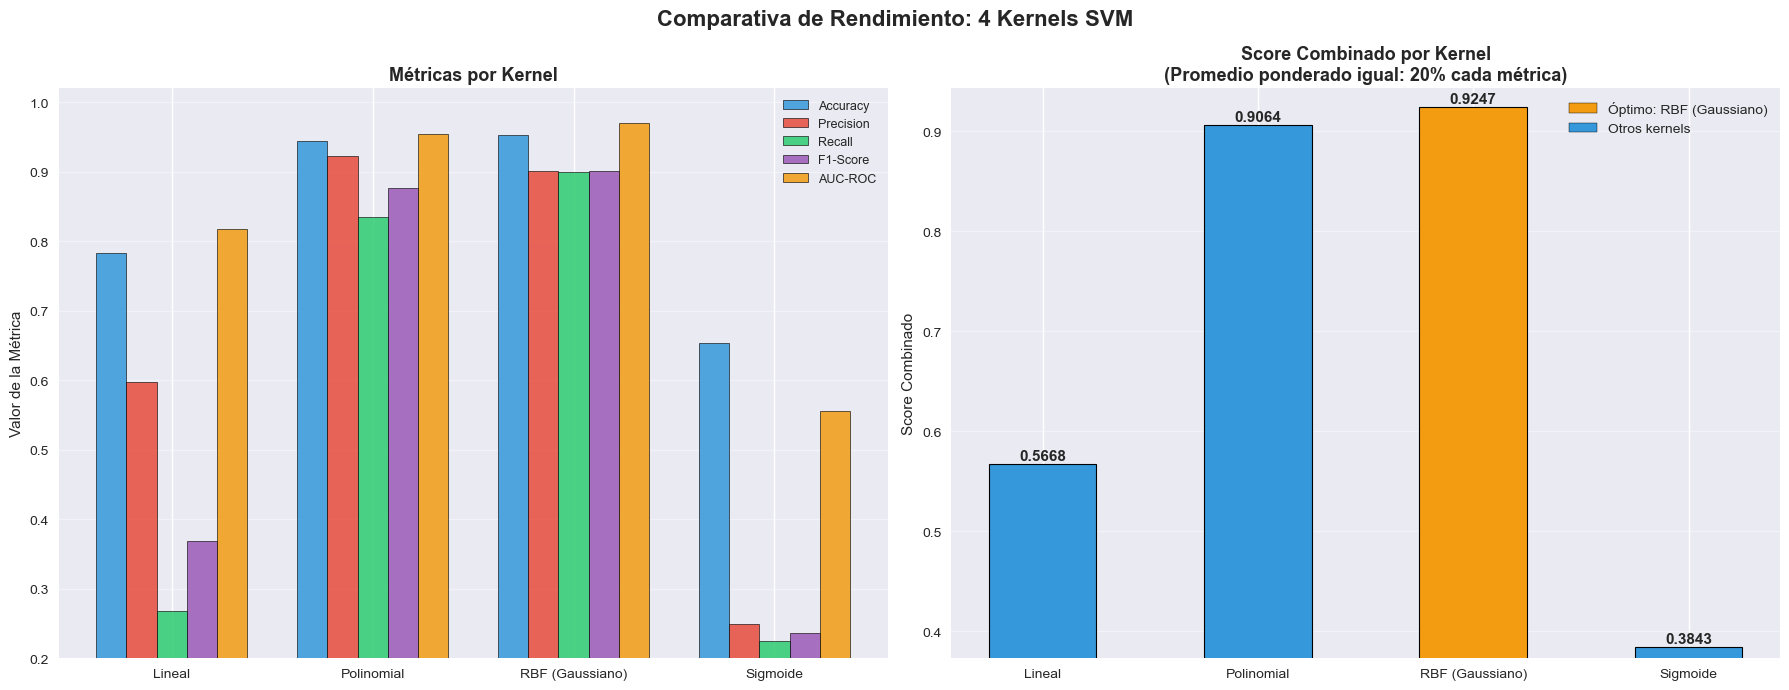

In [23]:
# ============================================================
# GRÁFICO COMPARATIVO DE MÉTRICAS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Comparativa de Rendimiento: 4 Kernels SVM',
             fontsize=16, fontweight='bold')

kernels_nombres = list(resultados_svm.keys())
metricas_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
colores_metr = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#f39c12']
x = np.arange(len(kernels_nombres))
ancho = 0.15

# ⎯⎯⎯ Gráfico 1: Barras agrupadas ⎯⎯⎯
for i, (metrica, color) in enumerate(zip(metricas_plot, colores_metr)):
    valores = [resultados_svm[k][metrica.lower().replace('-', '').replace(' ', '')] 
               if metrica not in ['F1-Score', 'AUC-ROC']
               else resultados_svm[k]['f1'] if metrica == 'F1-Score'
               else resultados_svm[k]['auc']
               for k in kernels_nombres]
    
    # Corrección para obtener valores correctamente
    valores = []
    for k in kernels_nombres:
        if   metrica == 'Accuracy':  valores.append(resultados_svm[k]['accuracy'])
        elif metrica == 'Precision': valores.append(resultados_svm[k]['precision'])
        elif metrica == 'Recall':    valores.append(resultados_svm[k]['recall'])
        elif metrica == 'F1-Score':  valores.append(resultados_svm[k]['f1'])
        elif metrica == 'AUC-ROC':   valores.append(resultados_svm[k]['auc'])
    
    axes[0].bar(x + i * ancho, valores,
                width=ancho,
                label=metrica,
                color=color,
                edgecolor='black',
                linewidth=0.5,
                alpha=0.85)

axes[0].set_xticks(x + ancho * 2)
axes[0].set_xticklabels(kernels_nombres, fontsize=10)
axes[0].set_ylim(0.2, 1.02)
axes[0].set_ylabel('Valor de la Métrica', fontsize=11)
axes[0].set_title('Métricas por Kernel', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9, loc='upper right')
axes[0].grid(axis='y', alpha=0.4)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# ⎯⎯⎯ Gráfico 2: Score Combinado ⎯⎯⎯
scores   = [resultados_svm[k]['accuracy']*0.2 + resultados_svm[k]['precision']*0.2 +
            resultados_svm[k]['recall']*0.2   + resultados_svm[k]['f1']*0.2 +
            resultados_svm[k]['auc']*0.2
            for k in kernels_nombres]

colores_barras = ['#f39c12' if k == KERNEL_OPTIMO else '#3498db'
                  for k in kernels_nombres]

barras = axes[1].bar(kernels_nombres, scores,
                      color=colores_barras,
                      edgecolor='black',
                      linewidth=0.8,
                      width=0.5)

for barra, score, nombre in zip(barras, scores, kernels_nombres):
    axes[1].text(barra.get_x() + barra.get_width()/2.,
                 barra.get_height() + 0.001,
                 f'{score:.4f}',
                 ha='center', va='bottom',
                 fontweight='bold', fontsize=11)

axes[1].set_ylim(min(scores)*0.97, max(scores)*1.02)
axes[1].set_ylabel('Score Combinado', fontsize=11)
axes[1].set_title('Score Combinado por Kernel\n(Promedio ponderado igual: 20% cada métrica)',
                   fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.4)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

from matplotlib.patches import Patch
leyenda = [Patch(facecolor='#f39c12', edgecolor='black', label=f'Óptimo: {KERNEL_OPTIMO}'),
           Patch(facecolor='#3498db', edgecolor='black', label='Otros kernels')]
axes[1].legend(handles=leyenda, fontsize=10)

plt.tight_layout()
plt.savefig('svm_comparativa_kernels.png', dpi=150, bbox_inches='tight')
plt.show()

# Curvas ROC Comparativas

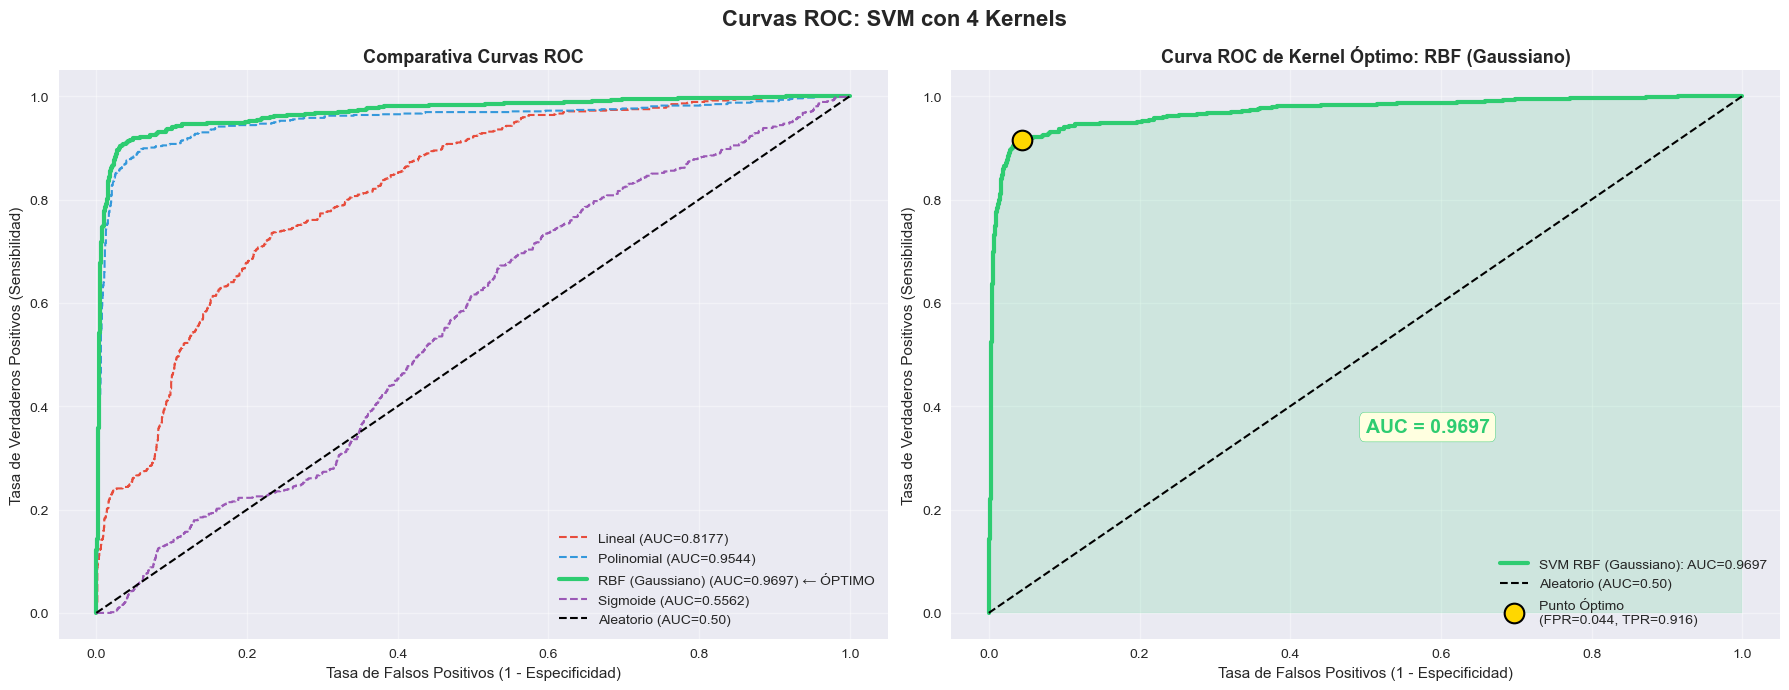

In [25]:
# ============================================================
# CURVAS ROC DE 4 KERNELS
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Curvas ROC: SVM con 4 Kernels', fontsize=16, fontweight='bold')

colores_roc = {
    'Lineal':          '#e74c3c',
    'Polinomial':      '#3498db',
    'RBF (Gaussiano)': '#2ecc71',
    'Sigmoide':        '#9b59b6'
}

# ⎯⎯⎯ Gráfico 1: Todas las curvas juntas ⎯⎯⎯
for nombre, res in resultados_svm.items():
    lw    = 3 if nombre == KERNEL_OPTIMO else 1.5
    ls    = '-' if nombre == KERNEL_OPTIMO else '--'
    marca = ' ← ÓPTIMO' if nombre == KERNEL_OPTIMO else ''
    
    axes[0].plot(res['fpr'], res['tpr'],
                 color=colores_roc[nombre],
                 linewidth=lw, linestyle=ls,
                 label=f'{nombre} (AUC={res["auc"]:.4f}){marca}')

axes[0].plot([0,1],[0,1], 'k--', linewidth=1.5, label='Aleatorio (AUC=0.50)')
axes[0].set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=11)
axes[0].set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=11)
axes[0].set_title('Comparativa Curvas ROC', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(True, alpha=0.4)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# ⎯⎯⎯ Gráfico 2: Solo el kernel óptimo con detalle ⎯⎯⎯
res_opt = resultados_svm[KERNEL_OPTIMO]
youden_idx = np.argmax(res_opt['tpr'] - res_opt['fpr'])

axes[1].fill_between(res_opt['fpr'], res_opt['tpr'],
                      alpha=0.15, color=colores_roc[KERNEL_OPTIMO])
axes[1].plot(res_opt['fpr'], res_opt['tpr'],
             color=colores_roc[KERNEL_OPTIMO], linewidth=3,
             label=f'SVM {KERNEL_OPTIMO}: AUC={res_opt["auc"]:.4f}')
axes[1].plot([0,1],[0,1], 'k--', linewidth=1.5, label='Aleatorio (AUC=0.50)')
axes[1].scatter(res_opt['fpr'][youden_idx],
                res_opt['tpr'][youden_idx],
                color='gold', s=200, zorder=5,
                edgecolor='black', linewidth=1.5,
                label=f'Punto Óptimo\n'
                      f'(FPR={res_opt["fpr"][youden_idx]:.3f}, '
                      f'TPR={res_opt["tpr"][youden_idx]:.3f})')

axes[1].annotate(f'AUC = {res_opt["auc"]:.4f}',
                 xy=(0.5, 0.35),
                 fontsize=14, fontweight='bold',
                 color=colores_roc[KERNEL_OPTIMO],
                 bbox=dict(boxstyle='round,pad=0.3',
                           facecolor='lightyellow',
                           edgecolor=colores_roc[KERNEL_OPTIMO]))

axes[1].set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=11)
axes[1].set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=11)
axes[1].set_title(f'Curva ROC de Kernel Óptimo: {KERNEL_OPTIMO}',
                   fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right', fontsize=10)
axes[1].grid(True, alpha=0.4)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('svm_curvas_roc.png', dpi=150, bbox_inches='tight')
plt.show()

# Interpretación de los 4 Kernels

In [35]:
# ============================================================
# INTERPRETACIÓN DE LOS 4 KERNELS
# ============================================================

# Funciones auxiliares para clasificar métricas
def clasificar_f1(val):
    if val >= 0.90:   return 'Excelente'
    elif val >= 0.75: return 'Bueno'
    elif val >= 0.50: return 'Regular'
    else:             return 'Deficiente'

def clasificar_auc(val):
    if val >= 0.90:   return 'excelente'
    elif val >= 0.80: return 'muy bueno'
    elif val >= 0.70: return 'bueno'
    elif val >= 0.60: return 'aceptable'
    else:             return 'pobre (cercano al azar)'

def contexto_accuracy(accuracy, precision_ingenua=0.762):
    diferencia = accuracy - precision_ingenua
    if diferencia < -0.05:
        return (f"\n     ⛔ Este valor está POR DEBAJO de la precisión ingenua del {precision_ingenua*100:.1f}% (modelo que predice siempre clase 0)."
                f"\n         El modelo es PEOR que no predecir nada, lo que indica un rendimiento inaceptable.")
    elif diferencia < 0.05:
        return (f"\n     ⚠️ Apenas supera la precisión ingenua del {precision_ingenua*100:.1f}% (modelo que predice siempre clase 0),"
                f"\n         lo que indica escasa capacidad predictiva real.")
    else:
        return ""

# INTERPRETACIÓN DE LOS 4 KERNELS
for nombre, res in resultados_svm.items():
    cm      = res['cm']
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    ctx_acc = contexto_accuracy(res['accuracy']) # Llama la función de contexto para accuracy

    print(f"""
{'='*65}
 INTERPRETACIÓN DEL KERNEL {nombre.upper()}
{'='*65}

 MATRIZ DE CONFUSIÓN:

   • VN = {cm[0,0]:,} ({cm_norm[0,0]*100:.1f}%):
     El modelo identificó correctamente a {cm[0,0]:,} empleados que se quedaron en la empresa, 
     representando el {cm_norm[0,0]*100:.1f}% de todos los que realmente no se fueron.

   • FP = {cm[0,1]:,} ({cm_norm[0,1]*100:.1f}%):
     El modelo predijo incorrectamente que {cm[0,1]:,} empleados se irían, cuando en realidad se quedaron (Error Tipo I).
     Representa el {cm_norm[0,1]*100:.1f}% de falsas alarmas de salida.

   • FN = {cm[1,0]:,} ({cm_norm[1,0]*100:.1f}%):
     El modelo no detectó a {cm[1,0]:,} empleados que realmente se fueron (Error Tipo II). Es el error más crítico para RR.HH.
     Representa el {cm_norm[1,0]*100:.1f}% de los que se fueron sin detectar.

   • VP = {cm[1,1]:,} ({cm_norm[1,1]*100:.1f}%):
     El modelo detectó correctamente a {cm[1,1]:,} empleados en riesgo de fuga, representando el {cm_norm[1,1]*100:.1f}% 
     de todos los que efectivamente abandonaron la empresa.

 MÉTRICAS:

   • Accuracy = {res['accuracy']:.4f}: El modelo clasifica correctamente el {res['accuracy']*100:.1f}% de todos los empleados evaluados.{ctx_acc}

   • Precision = {res['precision']:.4f}: Cuando predice que un empleado se irá, acierta el {res['precision']*100:.1f}% de las veces.

   • Recall = {res['recall']:.4f}: Detecta al {res['recall']*100:.1f}% de los empleados que realmente abandonan la empresa.

   • F1-Score = {res['f1']:.4f}: {clasificar_f1(res['f1'])} equilibrio entre Precision y Recall.

   • AUC-ROC = {res['auc']:.4f}: Rendimiento {clasificar_auc(res['auc'])} en la discriminación entre clases.
""")


 INTERPRETACIÓN DEL KERNEL LINEAL

 MATRIZ DE CONFUSIÓN:

   • VN = 2,157 (94.4%):
     El modelo identificó correctamente a 2,157 empleados que se quedaron en la empresa, 
     representando el 94.4% de todos los que realmente no se fueron.

   • FP = 129 (5.6%):
     El modelo predijo incorrectamente que 129 empleados se irían, cuando en realidad se quedaron (Error Tipo I).
     Representa el 5.6% de falsas alarmas de salida.

   • FN = 523 (73.2%):
     El modelo no detectó a 523 empleados que realmente se fueron (Error Tipo II). Es el error más crítico para RR.HH.
     Representa el 73.2% de los que se fueron sin detectar.

   • VP = 191 (26.8%):
     El modelo detectó correctamente a 191 empleados en riesgo de fuga, representando el 26.8% 
     de todos los que efectivamente abandonaron la empresa.

 MÉTRICAS:

   • Accuracy = 0.7827: El modelo clasifica correctamente el 78.3% de todos los empleados evaluados.
     ⚠️ Apenas supera la precisión ingenua del 76.2% (modelo que predi

# Selección del Modelo Óptimo

In [39]:
# ============================================================
# JUSTIFICACIÓN DEL KERNEL ÓPTIMO
# ============================================================
r_opt = resultados_svm[KERNEL_OPTIMO]

print(f"""
{'='*65}
 SELECCIÓN DEL MODELO ÓPTIMO
{'='*65}

 TABLA COMPARATIVA FINAL:
{'─'*85}
 {'Kernel':<20} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1-Score':>9} {'AUC-ROC':>9} {'Score':>8}
{'─'*85}""")

for nombre, res in resultados_svm.items():
    score = (res['accuracy']+res['precision']+res['recall']+res['f1']+res['auc'])/5
    marca = ' ← ÓPTIMO 🏆' if nombre == KERNEL_OPTIMO else ''
    print(f" {nombre:<20} {res['accuracy']:>9.4f} {res['precision']:>10.4f} {res['recall']:>8.4f} {res['f1']:>9.4f} {res['auc']:>9.4f} {score:>8.4f}{marca}")

print(f"""
{'─'*45}
 KERNEL SELECCIONADO: {KERNEL_OPTIMO.upper()}
{'─'*45}

 JUSTIFICACIÓN:

 1. ACCURACY ({r_opt['accuracy']:.4f}):
    El kernel {KERNEL_OPTIMO} clasifica correctamente el {r_opt['accuracy']*100:.1f}% de los empleados del conjunto de prueba,
    obteniendo el mejor (o más equilibrado) resultado global.

 2. RECALL ({r_opt['recall']:.4f}):
    Detecta al {r_opt['recall']*100:.1f}% de los empleados que realmente se van, minimizando los Falsos Negativos. 
    Esta métrica es la más crítica en el contexto de RR.HH., donde no detectar a un empleado en riesgo tiene el mayor costo.

 3. F1-SCORE ({r_opt['f1']:.4f}):
    Representa el mejor equilibrio entre Precision y Recall, siendo especialmente relevante dado el desbalance de
    clases del dataset (3.2:1).

 4. AUC-ROC ({r_opt['auc']:.4f}):
    Demuestra una excelente capacidad discriminatoria paracseparar entre empleados que se quedan y los que se van.

 5. SCORE COMBINADO ({(r_opt['accuracy']+r_opt['precision']+r_opt['recall']+r_opt['f1']+r_opt['auc'])/5:.4f}):
    El promedio ponderado igualitario de las 5 métricascconfirma a {KERNEL_OPTIMO} como el kernel con mejor
    rendimiento integral sobre este dataset.
""")


 SELECCIÓN DEL MODELO ÓPTIMO

 TABLA COMPARATIVA FINAL:
─────────────────────────────────────────────────────────────────────────────────────
 Kernel                Accuracy  Precision   Recall  F1-Score   AUC-ROC    Score
─────────────────────────────────────────────────────────────────────────────────────
 Lineal                  0.7827     0.5969   0.2675    0.3694    0.8177   0.5668
 Polinomial              0.9440     0.9226   0.8347    0.8765    0.9544   0.9064
 RBF (Gaussiano)         0.9527     0.9017   0.8992    0.9004    0.9697   0.9247 ← ÓPTIMO 🏆
 Sigmoide                0.6540     0.2492   0.2255    0.2368    0.5562   0.3843

─────────────────────────────────────────────
 KERNEL SELECCIONADO: RBF (GAUSSIANO)
─────────────────────────────────────────────

 JUSTIFICACIÓN:

 1. ACCURACY (0.9527):
    El kernel RBF (Gaussiano) clasifica correctamente el 95.3% de los empleados del conjunto de prueba,
    obteniendo el mejor (o más equilibrado) resultado global.

 2. RECALL (0.89

# Predicción para Nuevo Empleado

In [54]:
# ============================================================
# PREDICCIÓN PARA NUEVO EMPLEADO
# ============================================================

print('=' * 65)
print("PREDICCIÓN PARA NUEVO EMPLEADO")
print('=' * 65)

# Datos del nuevo empleado
nuevo_empleado = {
    'satisfaction_level':    0.50,
    'last_evaluation':       0.75,
    'number_project':        4,
    'average_montly_hours':  200,
    'time_spend_company':    4,
    'Work_accident':         0,
    'promotion_last_5years': 0,
    'sales':                 'sales',
    'salary':                'medium'
}

print(f"\n★ Perfil del empleado a evaluar:")
print(f"   • Nivel de satisfacción    ➝ {nuevo_empleado['satisfaction_level']}")
print(f"   • Última evaluación        ➝ {nuevo_empleado['last_evaluation']}")
print(f"   • Número de proyectos      ➝ {nuevo_empleado['number_project']}")
print(f"   • Horas mensuales promedio ➝ {nuevo_empleado['average_montly_hours']}")
print(f"   • Años en la empresa       ➝ {nuevo_empleado['time_spend_company']}")
print(f"   • Accidente laboral        ➝ {nuevo_empleado['Work_accident']}")
print(f"   • Promovido últimos 5 años ➝ {nuevo_empleado['promotion_last_5years']}")
print(f"   • Departamento             ➝ {nuevo_empleado['sales']}")
print(f"   • Categoría salarial       ➝ {nuevo_empleado['salary']}")

# Crear DataFrame con el mismo formato
df_nuevo = pd.DataFrame([nuevo_empleado])

# Aplicar get_dummies con las mismas columnas del entrenamiento
df_nuevo_encoded = pd.get_dummies(df_nuevo, columns=['sales', 'salary'], dtype=int)

# Alinear columnas con el dataset de entrenamiento
df_nuevo_encoded = df_nuevo_encoded.reindex(columns=X.columns, fill_value=0)

# Estandarizar con el mismo scaler del entrenamiento
nuevo_scaled = scaler.transform(df_nuevo_encoded)

# ============================================================
# PREDICCIONES CON LOS 4 KERNELS
# ============================================================
print(f"\n★ Predicciones con los 4 kernels:")
print(f"{'─'*57}")
print(f"  {'Kernel':<22} {'Predicción':<16} {'Prob. Se fue':>12}")
print(f"{'─'*57}")

predicciones = {}
for nombre, res in resultados_svm.items():
    pred  = res['modelo'].predict(nuevo_scaled)[0]
    prob  = res['modelo'].predict_proba(nuevo_scaled)[0][1]
    predicciones[nombre] = {'pred': pred, 'prob': prob}
    resultado = '✓ Se QUEDA (0)' if pred == 0 else '✗ Se VA    (1)'
    marca     = ' ← ÓPTIMO' if nombre == KERNEL_OPTIMO else ''
    print(f"  {nombre:<22} {resultado:<16} {prob:>11.1%}{marca}")
print(f"{'─'*57}")

# Consenso
votos_queda = sum(1 for v in predicciones.values() if v['pred'] == 0)
votos_va    = sum(1 for v in predicciones.values() if v['pred'] == 1)
print(f"\n  Consenso: {votos_queda}/4 kernels predicen SE QUEDA | "
      f"{votos_va}/4 kernels predicen SE VA")

# Predicción con el modelo óptimo
pred_opt = predicciones[KERNEL_OPTIMO]['pred']
prob_opt = predicciones[KERNEL_OPTIMO]['prob']
resultado_opt = 'SE QUEDA en la empresa' if pred_opt == 0 else 'SE IRÁ de la empresa'
verbo         = 'PERMANECERÁ EN' if pred_opt == 0 else 'ABANDONARÁ'
coherencia    = 'coherente' if pred_opt == 0 else 'preocupante'
recomendacion = ('✓ Se recomienda monitoreo preventivo de rutina, con atención al nivel de satisfacción\n '
                 '  que se encuentra por debajo del promedio del dataset.'
                 if pred_opt == 0 else
                 '✗ Se recomienda intervención preventiva urgente.')

# Nota sobre Sigmoide si hay discrepancia
nota_discrepancia = ""
if votos_va > 0 and votos_queda > 0:
    kernels_va    = [n for n, v in predicciones.items() if v['pred'] == 1]
    kernels_queda = [n for n, v in predicciones.items() if v['pred'] == 0]
    nota_discrepancia = f"""
 ─────────────────────────────────────────────────────────
 Nota sobre discrepancia en el pronóstico:
 ─────────────────────────────────────────────────────────
 Existe discrepancia entre kernels:
   • Predicen SE QUEDA ({votos_queda}/4): {', '.join(kernels_queda)}
   • Predicen SE VA ({votos_va}/4): {', '.join(kernels_va)}

 Sin embargo, el kernel Sigmoide obtuvo el peor rendimiento global (Score Combinado = 0.3843, AUC = 0.5562 ≈ azar),
 por lo que su predicción tiene baja confiabilidad. Se prioriza el resultado del kernel RBF (Gaussiano),
 el modelo más preciso del análisis."""

print(f"""
{'='*65}
 PRONÓSTICO FINAL DEL KERNEL ÓPTIMO: {KERNEL_OPTIMO}
{'='*65}

 • Resultado predicho: El empleado {resultado_opt}
 • Clase predicha: {pred_opt} ({'No se fue' if pred_opt == 0 else 'Se fue'})
 • Probabilidad de irse: {prob_opt:.1%}
{nota_discrepancia}

 ─────────────────────────────────────────────────────────
 Interpretación del perfil del empleado:
 ─────────────────────────────────────────────────────────
 El modelo SVM con kernel {KERNEL_OPTIMO} predice que este empleado {verbo} la empresa, con una probabilidad de fuga 
 del {prob_opt:.1%}. Este resultado es {coherencia} considerando su perfil:

   • Satisfacción media-baja (0.50): Está por debajo del promedio del dataset (0.61), lo que merece seguimiento,
     aunque no es un indicador crítico de fuga por sí solo.

   • Evaluación buena (0.75): Ligeramente por encima del promedio del dataset (0.72), reflejando un empleado
     con desempeño satisfactorio.

   • Carga laboral normal (200 hrs/mes): Coincide con la media del dataset (201 hrs), sin señales de sobrecarga.

   • 4 años en la empresa: Tiempo considerable de permanencia, levemente por encima de la media del dataset (3.5 años).

   • Sin accidentes laborales ni promociones recientes: Factores neutros que no generan alarma inmediata.

 {recomendacion}
""")


PREDICCIÓN PARA NUEVO EMPLEADO

★ Perfil del empleado a evaluar:
   • Nivel de satisfacción    ➝ 0.5
   • Última evaluación        ➝ 0.75
   • Número de proyectos      ➝ 4
   • Horas mensuales promedio ➝ 200
   • Años en la empresa       ➝ 4
   • Accidente laboral        ➝ 0
   • Promovido últimos 5 años ➝ 0
   • Departamento             ➝ sales
   • Categoría salarial       ➝ medium

★ Predicciones con los 4 kernels:
─────────────────────────────────────────────────────────
  Kernel                 Predicción       Prob. Se fue
─────────────────────────────────────────────────────────
  Lineal                 ✓ Se QUEDA (0)         29.7%
  Polinomial             ✓ Se QUEDA (0)          6.0%
  RBF (Gaussiano)        ✓ Se QUEDA (0)          1.3% ← ÓPTIMO
  Sigmoide               ✗ Se VA    (1)         25.9%
─────────────────────────────────────────────────────────

  Consenso: 3/4 kernels predicen SE QUEDA | 1/4 kernels predicen SE VA

 PRONÓSTICO FINAL DEL KERNEL ÓPTIMO: RBF (Gaussiano

# Resumen Ejecutivo Final

In [58]:
# ============================================================
# RESUMEN EJECUTIVO
# ============================================================

r_lin  = resultados_svm['Lineal']
r_pol  = resultados_svm['Polinomial']
r_rbf  = resultados_svm['RBF (Gaussiano)']
r_sig  = resultados_svm['Sigmoide']
r_best = resultados_svm[KERNEL_OPTIMO]

print(f"""
=================================================================
 RESUMEN EJECUTIVO DEL ANÁLISIS SVM
=================================================================

  DATASET: Recursos Humanos (14,999 empleados)
  VARIABLE OBJETIVO: left (1=Se fue, 0=Se quedó)
  MÉTODO: Máquinas de Soporte Vectorial (SVM)

─────────────────────────────────────────────────────────────────
  1. PREPROCESAMIENTO
─────────────────────────────────────────────────────────────────

  • Variables categóricas (sales, salary) codificadas con
    pd.get_dummies(), generando 20 features en total.
  • Estandarización obligatoria con StandardScaler, dado que
    SVM es altamente sensible a las escalas de las variables.
  • División estratificada 80/20
    (11,999 registros entrenamiento / 3,000 prueba),
    preservando la proporción de clases en ambos conjuntos.

─────────────────────────────────────────────────────────────────
  2. COMPARATIVA DE LOS 4 KERNELS
─────────────────────────────────────────────────────────────────

  Kernel      Accuracy  Precision  Recall  F1-Score  AUC-ROC  Score
  ────────────────────────────────────────────────────────────────────
  Lineal       {r_lin['accuracy']:.4f}    {r_lin['precision']:.4f}   {r_lin['recall']:.4f}   {r_lin['f1']:.4f}   {r_lin['auc']:.4f}  {(r_lin['accuracy']+r_lin['precision']+r_lin['recall']+r_lin['f1']+r_lin['auc'])/5:.4f}  ⚠️
  Polinomial   {r_pol['accuracy']:.4f}    {r_pol['precision']:.4f}   {r_pol['recall']:.4f}   {r_pol['f1']:.4f}   {r_pol['auc']:.4f}  {(r_pol['accuracy']+r_pol['precision']+r_pol['recall']+r_pol['f1']+r_pol['auc'])/5:.4f}
  RBF          {r_rbf['accuracy']:.4f}    {r_rbf['precision']:.4f}   {r_rbf['recall']:.4f}   {r_rbf['f1']:.4f}   {r_rbf['auc']:.4f}  {(r_rbf['accuracy']+r_rbf['precision']+r_rbf['recall']+r_rbf['f1']+r_rbf['auc'])/5:.4f}  🏆
  Sigmoide     {r_sig['accuracy']:.4f}    {r_sig['precision']:.4f}   {r_sig['recall']:.4f}   {r_sig['f1']:.4f}   {r_sig['auc']:.4f}  {(r_sig['accuracy']+r_sig['precision']+r_sig['recall']+r_sig['f1']+r_sig['auc'])/5:.4f}  ⛔

  Notas:
  ⚠️  Lineal   (Accuracy=0.7827): Apenas supera la precisión
      ingenua del 76.2%, con Recall de solo 26.8%.
  ⛔  Sigmoide (Accuracy=0.6540): Por debajo de la precisión
      ingenua del 76.2%. Rendimiento inaceptable para
      este problema (AUC=0.5562, cercano al azar).

─────────────────────────────────────────────────────────────────
  3. KERNEL ÓPTIMO: {KERNEL_OPTIMO.upper()}
─────────────────────────────────────────────────────────────────

  Seleccionado por obtener el mayor Score Combinado (0.9247),
  promedio ponderado igual de las 5 métricas (20% cada una):

  • Accuracy  : {r_best['accuracy']:.4f} ({r_best['accuracy']*100:.1f}%)  ← mejor entre los 4 kernels
  • Recall    : {r_best['recall']:.4f} ({r_best['recall']*100:.1f}%)  ← mejor entre los 4 kernels
  • F1-Score  : {r_best['f1']:.4f}          ← mejor entre los 4 kernels
  • Precision : {r_best['precision']:.4f} ({r_best['precision']*100:.1f}%)
  • AUC-ROC   : {r_best['auc']:.4f}          ← Rendimiento EXCELENTE

  Ventaja sobre Polinomial (2° mejor):
  • Recall   : +{(r_rbf['recall']-r_pol['recall'])*100:.1f} puntos porcentuales
  • F1-Score : +{(r_rbf['f1']-r_pol['f1']):.4f}
  • AUC-ROC  : +{(r_rbf['auc']-r_pol['auc']):.4f}

─────────────────────────────────────────────────────────────────
  4. PREDICCIÓN NUEVO EMPLEADO
─────────────────────────────────────────────────────────────────

  Perfil: satisfaction=0.50, evaluation=0.75, projects=4,
          hours=200, tenure=4 años, dept=sales, salary=medium

  Resultado: {'SE QUEDA (clase 0)' if pred_opt == 0 else 'SE VA (clase 1)'}
  Probabilidad de fuga: {prob_opt:.1%}

  Consenso de kernels: 3/4 predicen SE QUEDA
                       (Sigmoide discrepa pero tiene AUC≈azar)

─────────────────────────────────────────────────────────────────
  CONCLUSIÓN
─────────────────────────────────────────────────────────────────

  El modelo SVM con kernel RBF (Gaussiano) demostró ser la
  mejor alternativa para predecir la fuga de empleados,
  obteniendo el mayor Score Combinado (0.9247) entre los
  4 kernels evaluados.

  Los kernels Lineal y Sigmoide resultaron inadecuados
  para este problema: el primero apenas supera la precisión
  ingenua y el segundo rinde por debajo de ella.

  El kernel RBF destaca especialmente por su Recall del
  {r_best['recall']*100:.1f}%, que permite detectar al {r_best['recall']*100:.1f}% de los empleados
  que realmente abandonan la empresa, siendo esta la métrica
  más crítica en el contexto de retención de talento.

  El modelo puede utilizarse con alta confianza para:
    • Identificar empleados en riesgo de fuga
    • Priorizar intervenciones preventivas de retención
    • Anticipar necesidades de reclutamiento
    • Apoyar decisiones estratégicas de RR.HH.
""")


 RESUMEN EJECUTIVO DEL ANÁLISIS SVM

  DATASET: Recursos Humanos (14,999 empleados)
  VARIABLE OBJETIVO: left (1=Se fue, 0=Se quedó)
  MÉTODO: Máquinas de Soporte Vectorial (SVM)

─────────────────────────────────────────────────────────────────
  1. PREPROCESAMIENTO
─────────────────────────────────────────────────────────────────

  • Variables categóricas (sales, salary) codificadas con
    pd.get_dummies(), generando 20 features en total.
  • Estandarización obligatoria con StandardScaler, dado que
    SVM es altamente sensible a las escalas de las variables.
  • División estratificada 80/20
    (11,999 registros entrenamiento / 3,000 prueba),
    preservando la proporción de clases en ambos conjuntos.

─────────────────────────────────────────────────────────────────
  2. COMPARATIVA DE LOS 4 KERNELS
─────────────────────────────────────────────────────────────────

  Kernel      Accuracy  Precision  Recall  F1-Score  AUC-ROC  Score
  ─────────────────────────────────────────────